In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [155]:
# Load dataset
df = pd.read_csv("/workspaces/Global-energy-debt-shock-/Statistical Review of World Energy Narrow format.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (293234, 12)
   Country  Year ISO3166_alpha3  ISO3166_numeric  Region        SubRegion  \
0  Algeria  1965            DZA             12.0  Africa  Northern Africa   
1  Algeria  1965            DZA             12.0  Africa  Northern Africa   
2  Algeria  1965            DZA             12.0  Africa  Northern Africa   
3  Algeria  1965            DZA             12.0  Africa  Northern Africa   
4  Algeria  1965            DZA             12.0  Africa  Northern Africa   

   OPEC   EU  OECD  CIS                 Var     Value  
0   1.0  0.0   0.0  0.0           biogeo_ej  0.000000  
1   1.0  0.0   0.0  0.0   co2_combust_mtco2  5.568753  
2   1.0  0.0   0.0  0.0      co2_combust_pc  0.007229  
3   1.0  0.0   0.0  0.0  co2_combust_per_ej  4.242345  
4   1.0  0.0   0.0  0.0         coalcons_ej  0.002931  
<class 'pandas.DataFrame'>
RangeIndex: 293234 entries, 0 to 293233
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           ------------

In [156]:
print(df.describe())
print(df.isnull().sum())

                Year  ISO3166_numeric           OPEC             EU  \
count  293234.000000    221298.000000  221298.000000  221298.000000   
mean     1997.580605       417.837540       0.092093       0.264277   
std        16.469879       274.945624       0.289158       0.440949   
min      1965.000000         0.000000       0.000000       0.000000   
25%      1985.000000       158.000000       0.000000       0.000000   
50%      1999.000000       398.000000       0.000000       0.000000   
75%      2012.000000       682.000000       0.000000       1.000000   
max      2024.000000       894.000000       1.000000       1.000000   

                OECD            CIS          Value  
count  221298.000000  221298.000000  293234.000000  
mean        0.422087       0.057655     582.434492  
std         0.493893       0.233091    3827.552079  
min         0.000000       0.000000      -0.978634  
25%         0.000000       0.000000       0.036100  
50%         0.000000       0.000000       

In [157]:
df = df.drop(columns=["ISO3166_alpha3", "ISO3166_numeric"])

In [158]:
df_pivot = df.pivot_table(
    index=["Country", "Year"],
    columns="Var",
    values="Value"
).reset_index()

print(df_pivot.head())

Var  Country  Year  biodiesel_cons_kboed  biodiesel_cons_pj  \
0    Algeria  1965                   NaN                NaN   
1    Algeria  1966                   NaN                NaN   
2    Algeria  1967                   NaN                NaN   
3    Algeria  1968                   NaN                NaN   
4    Algeria  1969                   NaN                NaN   

Var  biodiesel_prod_kboed  biodiesel_prod_pj  biofuels_cons_ej  \
0                     NaN                NaN               NaN   
1                     NaN                NaN               NaN   
2                     NaN                NaN               NaN   
3                     NaN                NaN               NaN   
4                     NaN                NaN               NaN   

Var  biofuels_cons_kbd  biofuels_cons_kboed  biofuels_cons_pj  ...  \
0                  NaN                  NaN               NaN  ...   
1                  NaN                  NaN               NaN  ...   
2             

In [159]:
target = "co2_combust_mtco2"

In [160]:
df_pivot = df_pivot.fillna(0)

In [161]:
le = LabelEncoder()
df_pivot["Country"] = le.fit_transform(df_pivot["Country"])

In [162]:
y = df_pivot[target]

In [163]:
X = df_pivot.drop(columns=[target])

In [164]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [165]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [166]:
y_pred = model.predict(X_test)

In [167]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.9989476922043834
MAE: 20.41752496856025
RMSE: 98.92801931834913


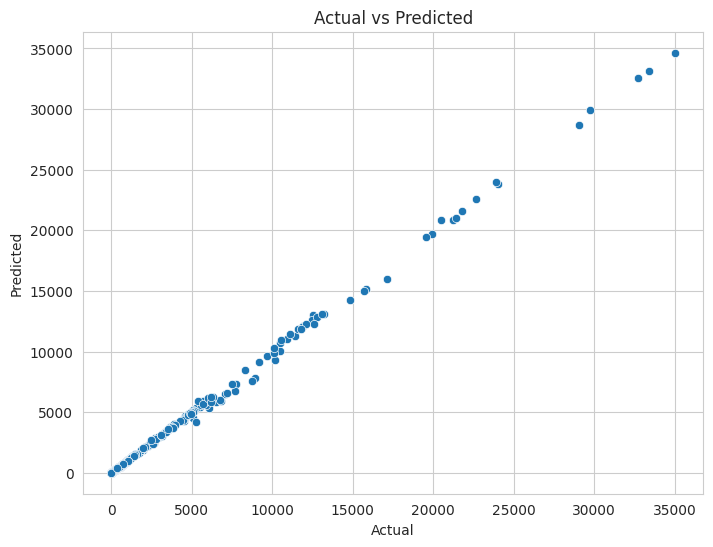

In [168]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [169]:
importance = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(10))

               Feature  Importance
86              tes_ej    0.821156
28   electbyfuel_hydro    0.076965
72  other_oil_cons_kbd    0.032601
51           hydro_twh    0.020132
52       hydro_twh_net    0.010716
50            hydro_ej    0.006269
40         gascons_bcm    0.004644
22           cobalt_kt    0.002695
39        gascons_bcfd    0.002005
18           co2_mtco2    0.001942


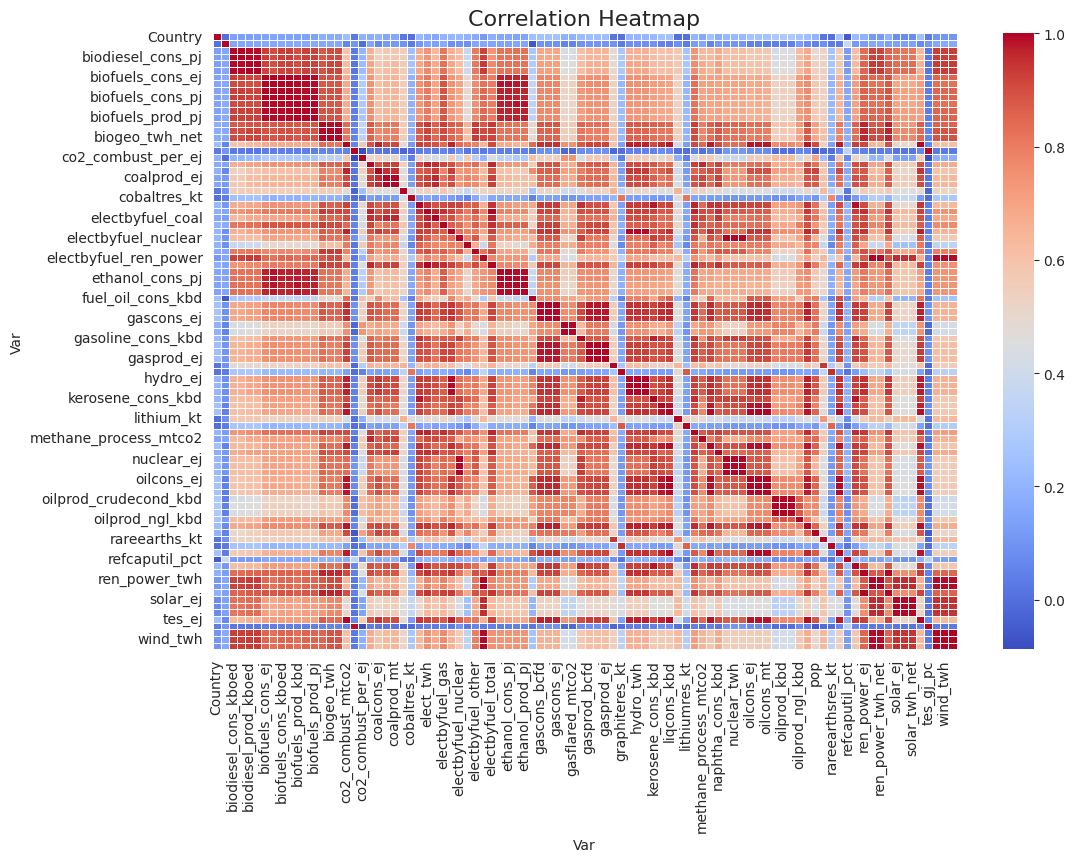

In [170]:
plt.figure(figsize=(12, 8))

corr = df_pivot.corr()

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",   # colorful gradient
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

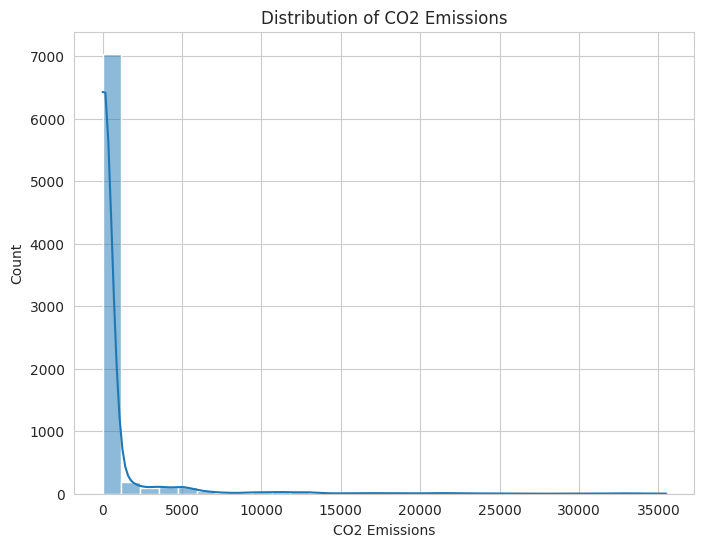

In [171]:
plt.figure(figsize=(8,6))
sns.histplot(df_pivot["co2_combust_mtco2"], bins=30, kde=True)
plt.title("Distribution of CO2 Emissions")
plt.xlabel("CO2 Emissions")
plt.show()

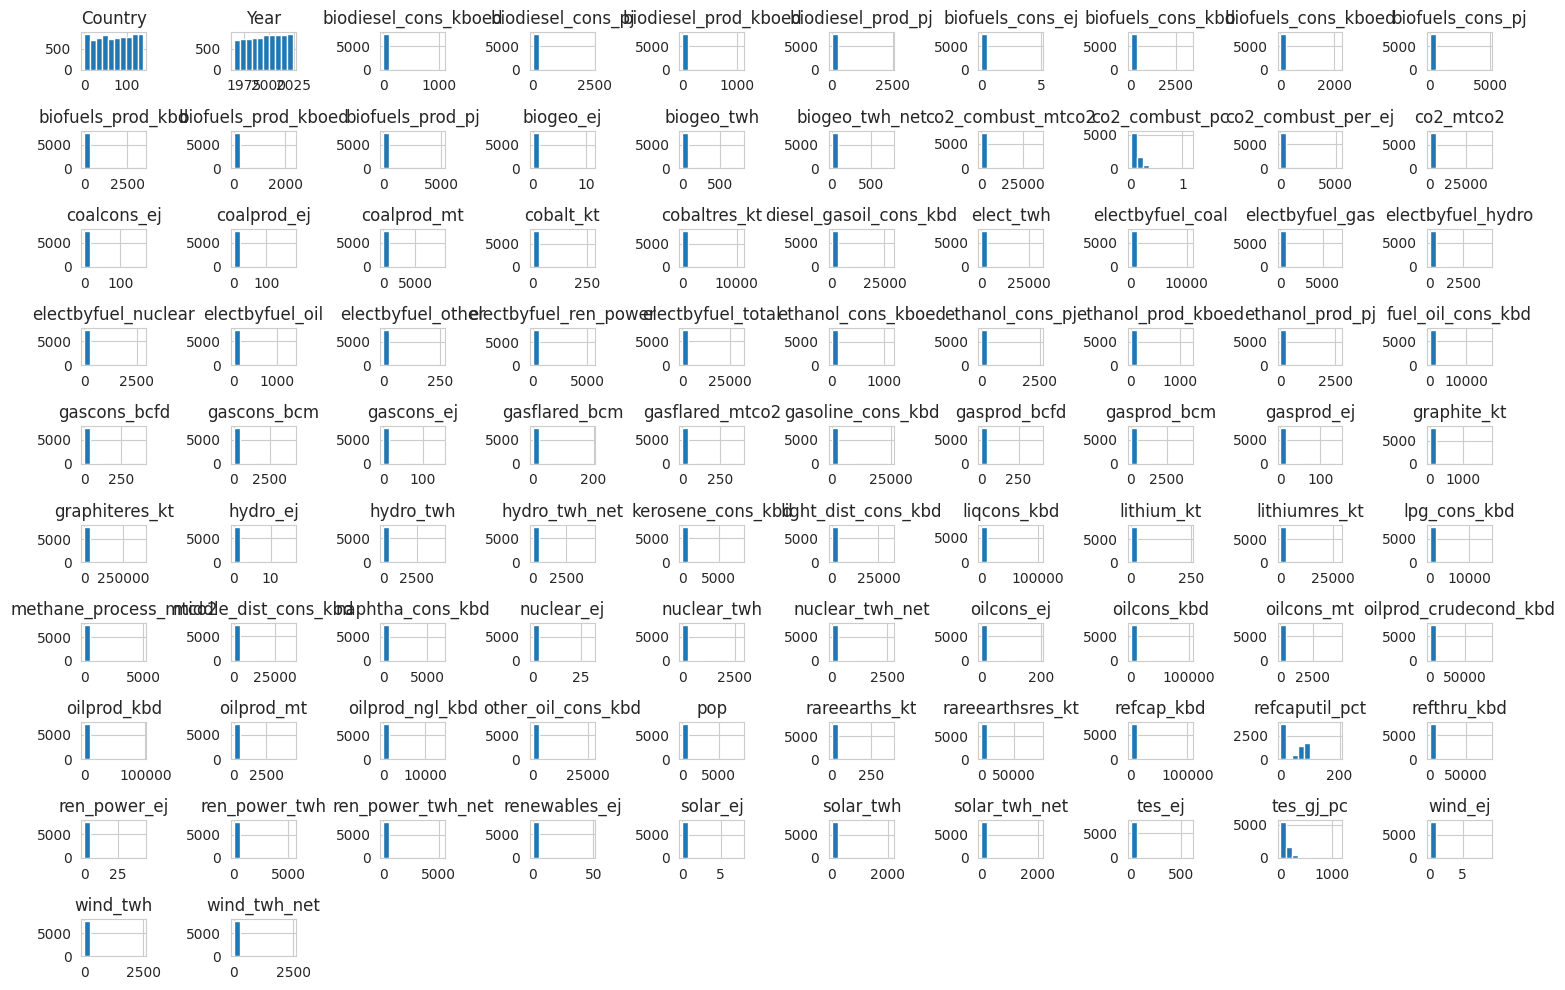

In [172]:
df_pivot.hist(figsize=(15,10), bins=10)
plt.tight_layout()
plt.show()

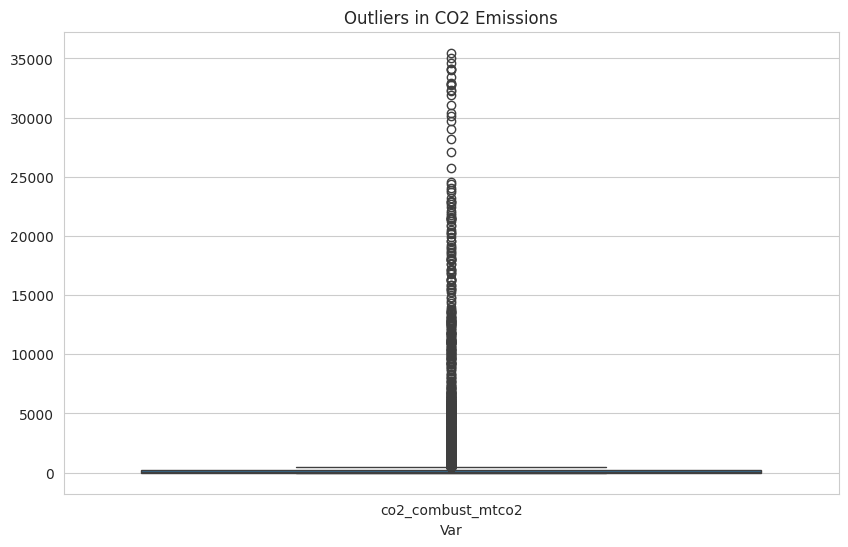

In [173]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_pivot[["co2_combust_mtco2"]])
plt.title("Outliers in CO2 Emissions")
plt.show()

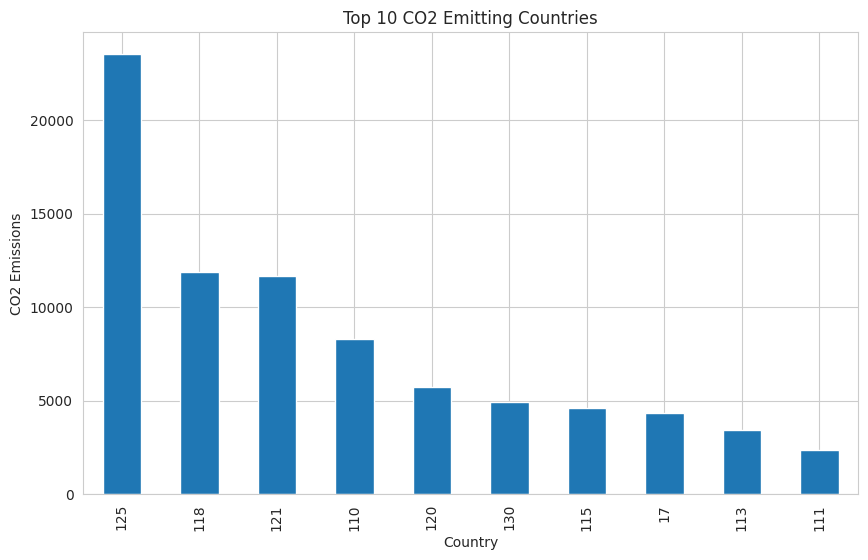

In [174]:
top_countries = df_pivot.groupby("Country")["co2_combust_mtco2"].mean().sort_values(ascending=False).head(10)

top_countries.plot(kind="bar", figsize=(10,6))
plt.title("Top 10 CO2 Emitting Countries")
plt.ylabel("CO2 Emissions")
plt.show()

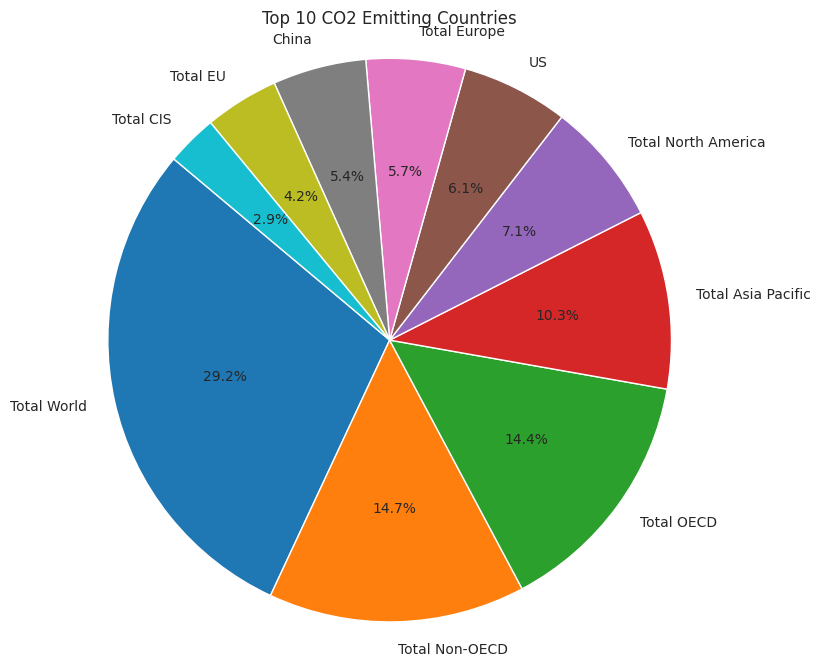

In [175]:
# Get top 10 countries based on average CO2 emissions
top_countries = (
    df_pivot.groupby("Country")["co2_combust_mtco2"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# If you encoded Country earlier, convert back to names
top_countries.index = le.inverse_transform(top_countries.index)

# Plot Pie Chart
plt.figure(figsize=(8,8))
plt.pie(
    top_countries,
    labels=top_countries.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Top 10 CO2 Emitting Countries")
plt.axis("equal")  # makes circle perfect
plt.show()

In [176]:
# Normalize data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [177]:
import pickle
with open('scaler.pkl','wb') as file1:  # wb is for write binary
    pickle.dump(scaler,file1)

In [178]:
with open('model.pkl', 'wb') as file2:
    pickle.dump(model,file2)

In [179]:
with open('model.pkl' , 'rb') as file4:  
    m= pickle.load(file4)

In [180]:
print(df.columns)

Index(['Country', 'Year', 'Region', 'SubRegion', 'OPEC', 'EU', 'OECD', 'CIS',
       'Var', 'Value'],
      dtype='str')
